In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cebra # had to remove a line (__version__) from idna __init__.py and install setuptools to make this work
import pandas as pd

/Users/kf02/Library/Mobile Documents/com~apple~CloudDocs/Work/Projects/Lifespan/.venv/lib/python3.11/site-packages/cebra/integrations/sklearn/cebra.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
from vizman import viz
viz.set_visual_style()
viz_sizes = viz.load_data_from_json("sizes.json")
viz_colors = viz.load_data_from_json("colors.json")
viz_cmaps = viz.give_colormaps()
sns_kwargs = {"cmap": viz_cmaps["bw_lr"],
              "xticklabels":False,
              "yticklabels":False,
              "rasterized":True}

In [4]:
lifespan_dataset = pd.read_pickle("../results/schaefer100/lifespan_dataset.pkl")

In [5]:
connectomes = np.stack(lifespan_dataset["connectome"].values)

In [6]:
connectomes_flattened = connectomes.reshape(connectomes.shape[0], -1)

In [7]:
connectomes_flattened.shape

(2112, 10000)

In [8]:
age_labels = lifespan_dataset["age"].values.squeeze()

In [9]:
import cebra

In [10]:
from cebra import CEBRA

In [11]:
lifespan_dataset.columns

Index(['id', 'age', 'sex', 'scores', 'connectome', 'communication',
       'structural_complexity', 'functional_complexity',
       'total_communication_strength', 'total_controllability'],
      dtype='object')

In [12]:
single_cebra_model = CEBRA(batch_size=1024,
                                 output_dimension=3,
                                 conditional="time_delta",
                                 max_iterations=10_000,
                                 temperature_mode="auto")

In [13]:
single_cebra_model.fit(connectomes_flattened,
                       np.stack((age_labels, 
                                 lifespan_dataset["scores"].values.squeeze()), axis=1))


,model_architecture,'offset1-model'
,device,'cuda_if_available'
,criterion,'infonce'
,distance,'cosine'
,conditional,'time_delta'
,temperature,1.0
,temperature_mode,'auto'
,min_temperature,0.1
,time_offsets,1
,delta,None
,max_iterations,10000


<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

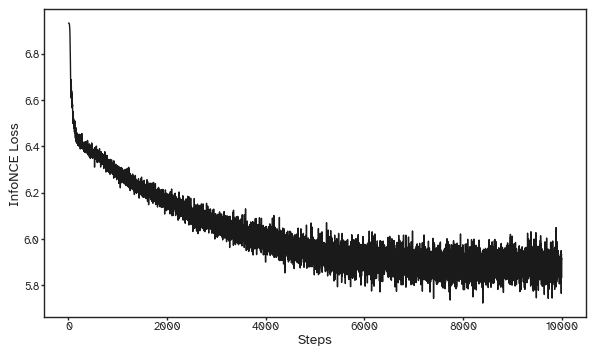

In [14]:
cebra.plot_loss(single_cebra_model,color="k")

<Axes3D: title={'center': 'CEBRA Embedding of Lifespan Dataset'}>

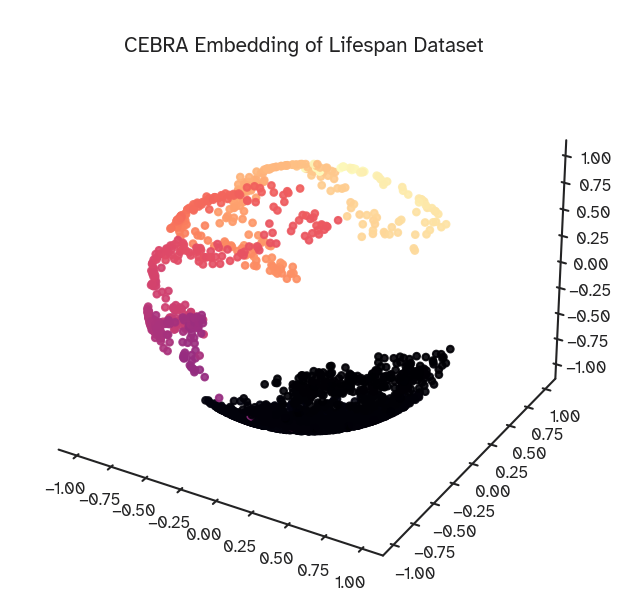

In [18]:
embedding = single_cebra_model.transform(connectomes_flattened)
cebra.plot_embedding(embedding,
                     alpha=0.9,
                     markersize=10,
                     embedding_labels=lifespan_dataset["age"].values, 
                     title="CEBRA Embedding of Lifespan Dataset",cmap="magma",dpi=150)

In [16]:
from cebra.integrations import plotly

In [20]:
fig = plotly.plot_embedding_interactive(embedding, embedding_labels=lifespan_dataset["age"].values, 
                                        markersize=5, figsize=(8,8),cmap = "magma",dpi=150,alpha=0.8)
fig.show()

<Figure size 1200x1200 with 0 Axes>

<Axes: title={'center': 'CEBRA Embedding of Lifespan Dataset'}>

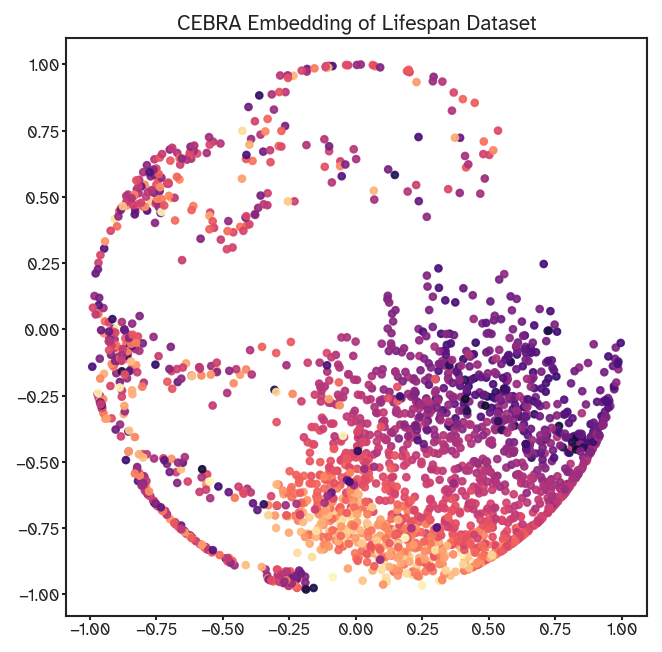

In [21]:
cebra.plot_embedding(embedding,
                     idx_order=(0,1),
                     alpha=0.9,
                     markersize=10,
                     embedding_labels=lifespan_dataset["scores"].values, 
                     title="CEBRA Embedding of Lifespan Dataset",cmap="magma",dpi=150)